# CS5489 - 机器学习
# 第 3a 讲 - 判别式分类器
### 香港城市大学 计算机科学系

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>本讲的主线是：直接学习决策边界或后验概率，而不先估计整个数据分布。</div>


# 大纲
1. 判别式线性分类器
2. 逻辑回归
3. 支持向量机（SVM）与核 SVM
4. 总结

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>3a 重点讲逻辑回归；SVM 和核方法的详细内容在 Lecture 3b。</div>


In [2]:
# 环境设置
%matplotlib inline
import matplotlib_inline   # 环境设置 output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # 以较大尺寸显示图像
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'DejaVu Sans']  # 中文字体回退列表
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats

# 使用生成式模型进行分类
- 构建分类器的步骤
  1. 收集训练数据（特征 $\mathbf{x}$ 和类别标签 $y$）。
  2. 学习类条件分布（CCD）$p(\mathbf{x}|y)$。
  3. 使用贝叶斯公式计算类别概率 $p(y|\mathbf{x})$。
- **注意：**数据首先用于学习 CCD，分类器反而是次要的产物。
  - 密度估计是一个“不适定”问题：应该使用哪种密度？需要多少数据？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>生成式方法解决了比“分类”更广的密度估计问题，因此对模型假设和数据量更敏感。</div>


- SVM 发明者 Vladimir Vapnik 的建议：
> 解决一个问题时，尽量不要把解决一个更一般的问题作为中间步骤。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>Vapnik 的意思是：如果目标只是分类，可以直接学习分类规则。</div>


- **判别式解决方案**
  - 直接求解分类器 $p(y|\mathbf{x})$！

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>逻辑回归就是直接建模 $p(y|\mathbf{x})$ 的典型判别式方法。</div>


- 术语
  - **“判别式”（Discriminative）**：学习如何利用特征直接区分各类。
  - **“生成式”（Generative）**：学习不同类别生成特征的方式。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>两类方法不是以“是否输出概率”区分，而是看它学习 $p(\mathbf{x}|y)$ 还是 $p(y|\mathbf{x})$。</div>


# 回顾高斯朴素贝叶斯分类器
- 类条件分布：假设所有高斯分布具有相同方差：
  - $p(\mathbf{x}|y=1) = \prod_{i=1}^D {\cal N}(x_i|\mu_i,\sigma^2)$
  - $p(\mathbf{x}|y=2) = \prod_{i=1}^D {\cal N}(x_i|\nu_i,\sigma^2)$
- 先验概率：
  - $p(y=1) = \pi_1$，$p(y=2) = \pi_2$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>“各类共享方差”是得到线性决策边界的关键假设。</div>


- 考察两个类条件分布的对数比：
$$\begin{aligned} \log\frac{p(\mathbf{x}|y=1)}{p(\mathbf{x}|y=2)} &= \log \frac{\prod_{i=1}^D {\cal N}(x_i|\mu_i,\sigma^2)}{\prod_{i=1}^D {\cal N}(x_i|\nu_i,\sigma^2)}\\
&= \sum_{i=1}^D \log {\cal N}(x_i|\mu_i,\sigma^2) - \log {\cal N}(x_i|\nu_i,\sigma^2)\\
&=\sum_{i=1}^D -\frac{1}{2\sigma^2}(x_i -\mu_i)^2 +\frac{1}{2\sigma^2}(x_i -\nu_i)^2\\
&=\frac{1}{2\sigma^2}\sum_{i=1}^D (2x_i\mu_i-\mu_i^2-2x_i\nu_i +\nu_i^2)\\
&= \frac{1}{2\sigma^2}\sum_{i=1}^D 2(\mu_i-\nu_i)x_i - \mu_i^2 +\nu_i^2\end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>展开平方后，两类中的 $x_i^2$ 项由于共享方差而相互抵消，最终只剩下 $x_i$ 的一次项。</div>


- 因此：
$$\begin{aligned} \log \frac{p(\mathbf{x}|y=1)}{p(\mathbf{x}|y=2)} = \frac{1}{\sigma^2}\sum_{i=1}^D (\mu_i - \nu_i)x_i + \frac{1}{2\sigma^2}\sum_{i=1}^D (\nu_i^2 -\mu_i^2)\end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>该式已经具有“特征加权和＋常数”的线性形式。</div>


- **贝叶斯决策规则：**计算每个类别的后验概率 $p(y=j|\mathbf{x})$。
  - 在以下条件成立时选择类别 1：
$$ \begin{aligned}\log p(y=1|\mathbf{x}) &> \log p(y=2|\mathbf{x}) \\
  \log p(\mathbf{x}|y=1) + \log p(y=1) &> \log p(\mathbf{x}|y=2) + \log p(y=2) \\
 \log \frac{p(\mathbf{x}|y=1)}{p(\mathbf{x}|y=2)} + \log \frac{p(y=1)}{p(y=2)} &> 0 \end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>取对数不会改变概率大小顺序，却能把乘法变成加法，也更利于数值计算。</div>


- 代入类条件分布和先验概率，可得贝叶斯决策规则：
  - 在以下条件成立时选择类别 $y=1$：
$$\sum_{i=1}^D \frac{1}{\sigma^2}(\mu_i - \nu_i)x_i + \frac{1}{2\sigma^2}\sum_{i=1}^D (\nu_i^2 -\mu_i^2) + \log \frac{\pi_1}{\pi_2} > 0$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>先验概率比 $\log(\pi_1/\pi_2)$ 只进入偏置项，因而会平移决策边界。</div>


In [3]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（变色鸢尾=1，弗吉尼亚鸢尾=2）

print(X.shape)

(100, 2)


In [4]:
# 从 sklearn 创建高斯朴素贝叶斯模型
model = naive_bayes.GaussianNB()

# 拟合模型
model.fit(X, Y)
v = mean(model.var_.ravel())  # 将其设为共享方差
model.var_[:] = v

In [5]:
# 散点图颜色映射：类别 1 为红色，类别 2 为绿色
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

axbox = [2.5, 7, 1.5, 4] # 统一的坐标轴范围

# 用于统一设置图形的函数
def irisaxis():
    plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
    plt.axis([2.5, 7, 1.5, 4]); plt.grid(True)

In [6]:
## 可视化  ###############################################################################################
def plot_ellipse(ax, musigma, color="k", lw=1):
    """
    参考：
    http://stackoverflow.com/questions/17952171/not-sure-how-to-fit-data-with-a-gaussian-python.
    """

    mu, sigma = musigma
    
    # 计算特征值及对应的特征向量
    vals, vecs = linalg.eigh(sigma)

    # 使用第一个特征向量计算椭圆的倾斜角
    x, y = vecs[:, 0]
    theta = degrees(arctan2(y, x))

    # 特征值给出椭圆沿各特征向量方向的长度
    # 绘制 2 个标准差的范围
    w, h = 2 * sqrt(vals) * 2

    #ax.tick_params(axis='both', which='major', labelsize=20)
    ellipse = matplotlib.patches.Ellipse(mu, w, h, angle=theta, fill=False, color=color, lw=lw)  # color="k")
    ellipse.set_clip_box(ax.bbox)
    ellipse.set_alpha(1.0)
    ax.add_artist(ellipse) 

In [7]:
def plot_posterior(model, axbox, mycmap, showlabels=True):
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # 创建用于计算后验概率的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    # 计算后验概率
    post = model.predict_proba(allpts)
    # 取出类别 2 的后验概率，并重塑为网格
    post1 = post[:,1].reshape(xgrid0.shape)

    # 绘制后验概率等高线和决策边界
    plt.imshow(post1, origin='lower', extent=axbox, alpha=0.50, cmap=mycmap)
    if showlabels:
        plt.colorbar(shrink=0.6)
    CS = plt.contour(xr[0], xr[1], post1, cmap=mycmap, levels=[0.1, 0.3, 0.7, 0.9], alpha=0.8)
    if showlabels:
        #plt.colorbar(CS)
        plt.clabel(CS, inline=1, fontsize=10)
    plt.contour(xr[0], xr[1], post1, levels=[0.5], linestyles='dashed', colors='black')
    irisaxis()

In [8]:
pfig = plt.figure(figsize=(9,8))
plot_posterior(model, axbox, mycmap, showlabels=True)
plot_ellipse(plt.gca(), (model.theta_[0,:], diag(model.var_[0,:])), color='r')
plot_ellipse(plt.gca(), (model.theta_[1,:], diag(model.var_[1,:])), color='g')
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.title('训练数据与后验概率 p(y=2|x)');
plt.close()

- 示例

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>图中概率为 0.5 的等高线就是决策边界。</div>


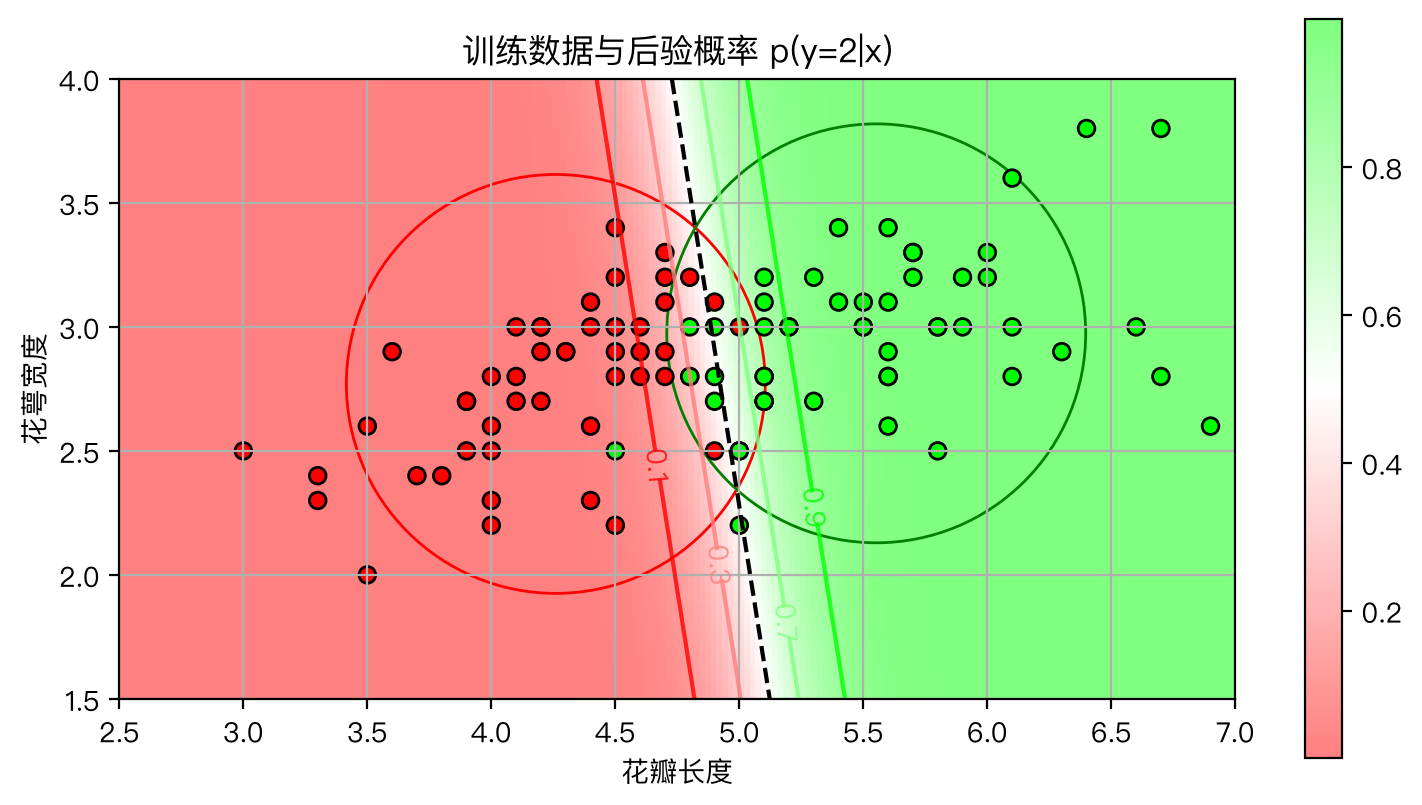

In [9]:
pfig

- 此时的贝叶斯决策规则是一个**线性**函数：
  - 在以下条件成立时选择类别 $y=1$：
$$\sum_{i=1}^D \underbrace{\frac{1}{\sigma^2}(\mu_i - \nu_i)}_{w_i}x_i + \underbrace{\frac{1}{2\sigma^2}\sum_{i=1}^D (\nu_i^2 -\mu_i^2) + \log \frac{\pi_1}{\pi_2}}_{b} > 0$$
    - $w_i$ 是每个特征的权重。
    - $b$ 是偏置项。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>如果两类拥有不同的协方差，二次项一般不会抵消，决策边界可能变成二次曲线或曲面。</div>


- 此时的贝叶斯决策规则是一个**线性**分类器：
  - 当 $\sum_{i=1}^D w_i x_i + b > 0$ 时选择类别 $y=1$。
  - 等价地，$f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b > 0$。
- 这里的权重 $\mathbf{w}$ 是通过学习类条件分布得到的：
  - 假设特征服从共享方差的朴素贝叶斯高斯分布。
  - 因为学习了每个类别如何生成数据，所以它是生成式模型。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>“决策边界是线性的”并不等于“模型是判别式的”；此处的线性边界仍来自生成式建模。</div>


- 如何以判别式方式学习线性分类器？
  - 直接学习后验概率 $p(y|\mathbf{x})$。
  - 下面考察一个通用线性分类器。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>接下来不再估计高斯分布参数，而是直接优化 $\mathbf w$ 和 $b$。</div>


# 线性分类器
- **设定**
  - 观测（特征向量）$\mathbf{x}\in \mathbb{R}^d$。
  - 类别 $y \in \{-1, +1\}$。
- **目标：**给定特征向量 $\mathbf{x}$，预测其类别 $y$。
  - 计算特征向量 $\mathbf{x}$ 的一个线性函数：
    - $f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b = \sum_{j=1}^d w_j x_j + b$。
      - $\mathbf{w}\in \mathbb{R}^d$ 是线性函数的权重。
      - 将每个特征值与对应权重相乘，然后求和。
  - 根据函数值进行预测：
    - 若 $f(\mathbf{x}) > 0$，预测为类别 $y=1$。
    - 若 $f(\mathbf{x}) < 0$，预测为类别 $y=-1$。
    - 等价地，$y = \mathrm{sign}(f(\mathbf{x}))$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>$f(\mathbf{x})$ 是带符号的分类得分；符号决定类别，绝对值反映样本离边界的程度。</div>


# 几何解释
- 线性分类器将特征空间分成两个**半空间**：
  - 分别对应于类别 $+1$ 和类别 $-1$ 的特征值。
  - 类别边界与 $\mathbf{w}$ 垂直。
    - 该边界也称为**分离超平面**。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>$\mathbf w$ 改变方向会旋转边界，$b$ 改变则会平移边界。</div>


  - 示例：
  $$\mathbf{w} = \begin{bmatrix}2\\1\end{bmatrix}, b=0$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>在该例中，边界方程为 $2x_1+x_2=0$，法向量为 $[2,1]^T$。</div>


In [10]:
def drawplane(w, b, wlabel=None, poscol=None, negcol=None):
    # w^Tx + b = 0
    # w0 x0 + w1 x1 + b = 0
    # x1 = -w0/w1 x0 - b / w1

    # 直线
    x0 = linspace(-10,10)
    x1 = -w[0]/w[1] * x0 - b / w[1]
    
    
    # 填充正半空间或负半空间
    if (poscol):
        polyx = [x0[0], x0[-1], x0[-1], x0[0]]
        polyy = [x1[0], x1[-1], x1[0], x1[0]]
        plt.fill(polyx, polyy, poscol, alpha=0.2)
    
    if (negcol):
        polyx = [x0[0], x0[-1], x0[0], x0[0]]
        polyy = [x1[0], x1[-1], x1[-1], x1[0]]
        plt.fill(polyx, polyy, negcol, alpha=0.2)
        
    # 绘制直线
    plt.plot(x0, x1, 'k-', lw=2)

    # 向量 w
    if (wlabel):
        xp = array([0, -b/w[1]])
        xpw = xp+w
        plt.arrow(xp[0], xp[1], w[0], w[1], width=0.01, head_width=0.3, fc='black')
        plt.text(xpw[0]-0.5, xpw[1], wlabel)
    

In [11]:
linclass = plt.figure()
w = array([2, 1])
b = 0;

drawplane(w, b, '$\mathbf{w}$', 'b', 'r')

# 若干样本点
plt.plot([2.2,4,3], [-2,2,-1], 'bx')
plt.plot([-2.2,-4,-3], [2,1,-1], 'ro')

plt.text(-1.8,4, "$f(\mathbf{x}) = 0$", fontsize=12)
plt.text(4, 3.5, "$f(\mathbf{x})>0$\n类别 +1", ha="right", fontsize=12)
plt.text(-4, -3.5, "$f(\mathbf{x})<0$\n类别 -1", fontsize=12)

plt.xlabel('特征 $x_1$'); plt.ylabel('特征 $x_2$')
plt.axis('equal')
plt.axis([-5, 5, -5, 5]); plt.grid(True)
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


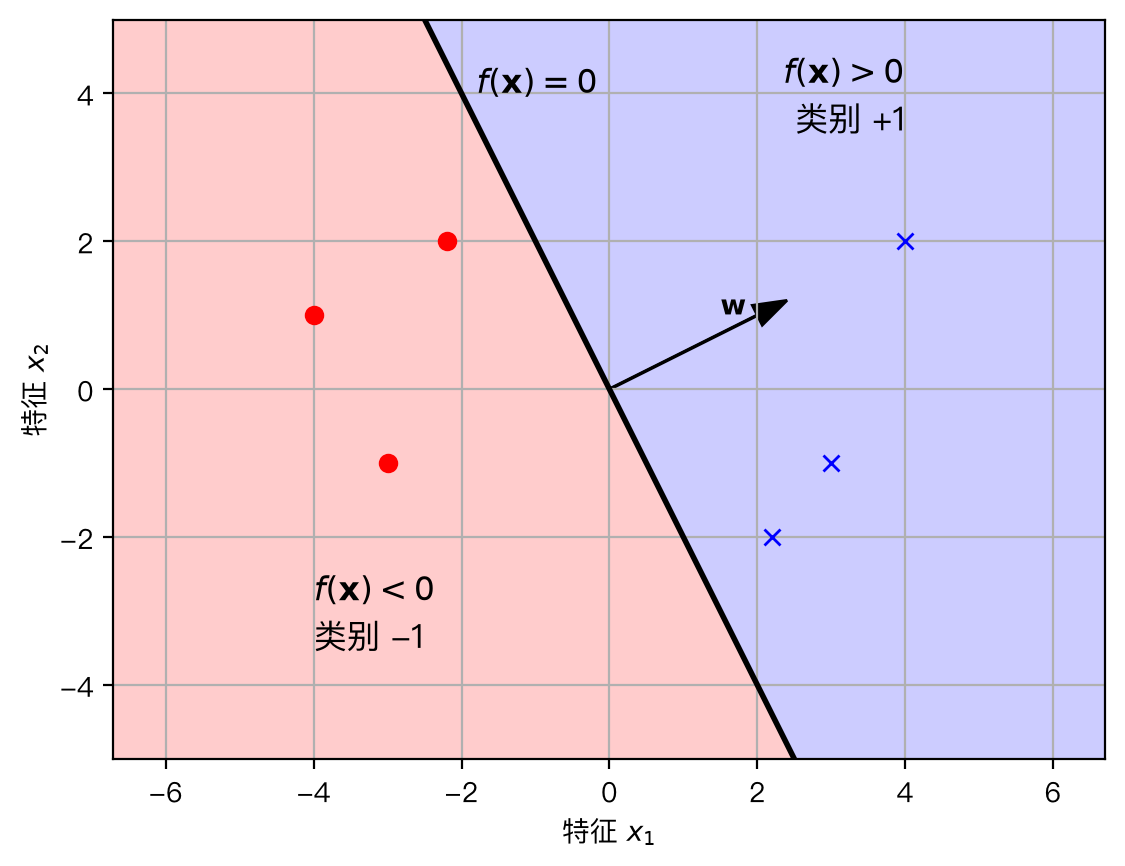

In [12]:
linclass

# 分离超平面
- 在 $d$ 维特征空间中，参数为 $\mathbf{w}\in\mathbb{R}^d$。
- 方程 $\mathbf{w}^T\mathbf{x} + b = 0$ 定义了一个 $d-1$ 维线性曲面：
  - $d=2$ 时，它是一条一维直线。
  - $d=3$ 时，它是一个二维平面。
  - 以此类推。
  - 一般地，我们称之为超平面。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>“线性”指决策函数对特征是一次的；在高维中仍统称为超平面。</div>


# 学习分类器
- 如何设定分类器参数 $(\mathbf{w}, b)$？
  - 从训练数据中学习。
- 不同分类器的区别在于学习参数 $(\mathbf{w},b)$ 时所使用的目标函数。
  - 下面考察两个例子：
    - 逻辑回归。
    - 支持向量机（SVM）。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>逻辑回归与线性 SVM 可使用同一个 $f(\mathbf{x})$，但它们的损失函数和学习原则不同。</div>


# 逻辑回归
- 使用概率方法：
  - 通过 **sigmoid 函数**将线性函数 $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$ 映射到 0 与 1 之间的概率值。
  - $\sigma(z) = \frac{1}{1+e^{-z}}$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>sigmoid 单调递增，且 $\sigma(0)=0.5$，所以概率阈值 0.5 对应的决策边界正是 $f(\mathbf{x})=0$。</div>


In [13]:
z = linspace(-5,5)
sigz = 1/(1+exp(-z))

sigmoidplot = plt.figure(figsize=(5,3))

plt.plot(z,sigz, 'b-')

plt.xlabel('$f(\mathbf{x})$'); plt.ylabel('$\sigma(f(\mathbf{x}))$')
plt.axis([-5, 5, 0, 1]); plt.grid(True)
plt.close()

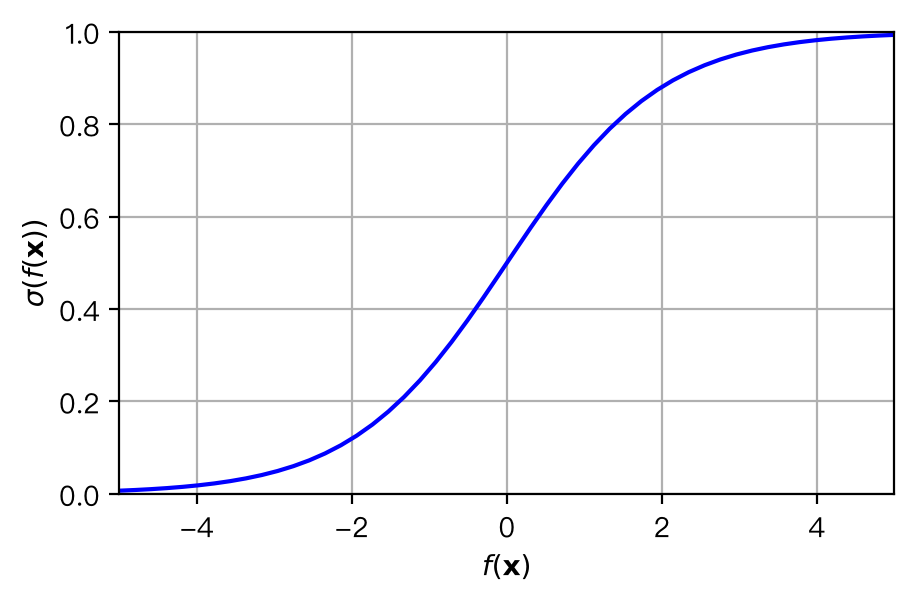

In [14]:
sigmoidplot

- 给定特征向量 $\mathbf{x}$，类别概率为：
  - $p(y=+1|\mathbf{x}) = \sigma( f(\mathbf{x}) )$
  - $p(y=-1|\mathbf{x}) = 1-\sigma( f(\mathbf{x}) )$
- 注意：这里直接建模类别的后验概率，而不是类条件分布 $p(\mathbf{x}|y)$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>二分类中两个概率之和为 1；分类和概率估计在同一模型中完成。</div>


In [15]:
x = linspace(-10,10, 100)
w = 2.0
b = -4.0
f = w*x+b
sf = 1/(1+exp(-f))
midx = -b/w

lrexample = plt.figure(figsize=(6,3))

plt.plot(x,sf, 'b-', label="$p(y=+1|\mathbf{x})$")
plt.plot(x,1-sf, 'r-', label="$p(y=-1|\mathbf{x})$")
plt.plot([midx, midx], [0.0,1.2], 'k--', label="决策边界")

plt.arrow(midx-0.1,1.05,-1.8,0,width=0.01)
plt.arrow(midx+0.1,1.05,1.8,0,width=0.01)
plt.text(midx+0.2,1.10,"类别 +1")
plt.text(midx-0.2,1.10,"类别 -1", horizontalalignment='right')
plt.legend(loc=0, framealpha=1, fontsize='medium')
plt.title('类别后验概率 $p(y|\mathbf{x})$');
plt.xlabel('特征 $\mathbf{x}$'); plt.ylabel('概率')
plt.axis([-7, 7, 0, 1.2]); plt.grid(True)
plt.close()

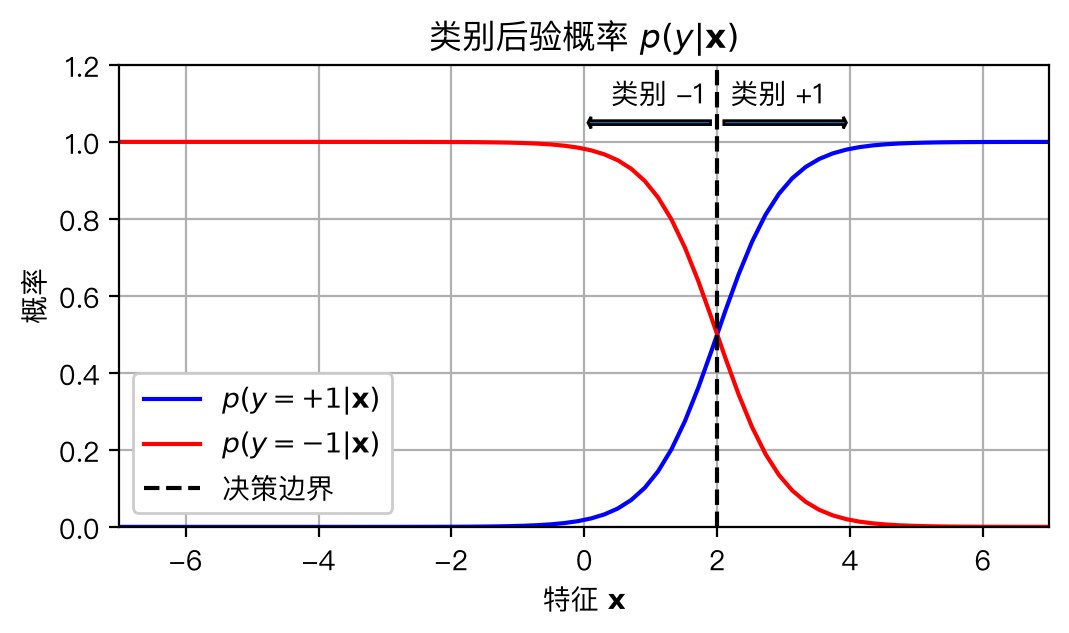

In [16]:
lrexample

# 学习参数
- 给定训练数据 $\{\mathbf{x}_i,y_i\}_{i=1}^N$，通过最大似然估计学习函数参数 $(\mathbf{w},b)$。
- 根据后验概率，最大化数据 $\{\mathbf{x}_i,y_i\}$ 的对数似然：
  $$(\mathbf{w}^*,b^*) = \mathop{\mathrm{argmax}}_{\mathbf{w},b} \sum_{i=1}^N \log p(y_i|\mathbf{x}_i)$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>最大化对数似然等价于最小化负对数似然；后者将导出逻辑损失。</div>


- 给定 $\mathbf{x}$ 时，后验概率是一个伯努利分布：
  $$p(y|\mathbf{x}) = \begin{cases}\sigma(f(\mathbf{x})), & y=1 \\ 1-\sigma(f(\mathbf{x})), & y=-1\end{cases}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>伯努利分布适用于只有两种可能结果的随机变量。</div>


- 注意以下性质：
  $$1-\sigma(z)=\sigma(-z)$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>这个对称性使两个类别的概率能统一写成 $\sigma(yf)$。</div>


In [17]:
z = linspace(-5,5)
sigz = 1/(1+exp(-z))
signz = 1/(1+exp(z))

sigmoidplot = plt.figure(figsize=(5,3))

plt.plot(z,sigz, 'b-', label='$\sigma(z)$')
plt.plot(z,signz, 'r-', label='$\sigma(-z) = 1-\sigma(z)$')

plt.xlabel('$f(\mathbf{x})$');
plt.axis([-5, 5, 0, 1]); plt.grid(True)
plt.legend()
plt.close()

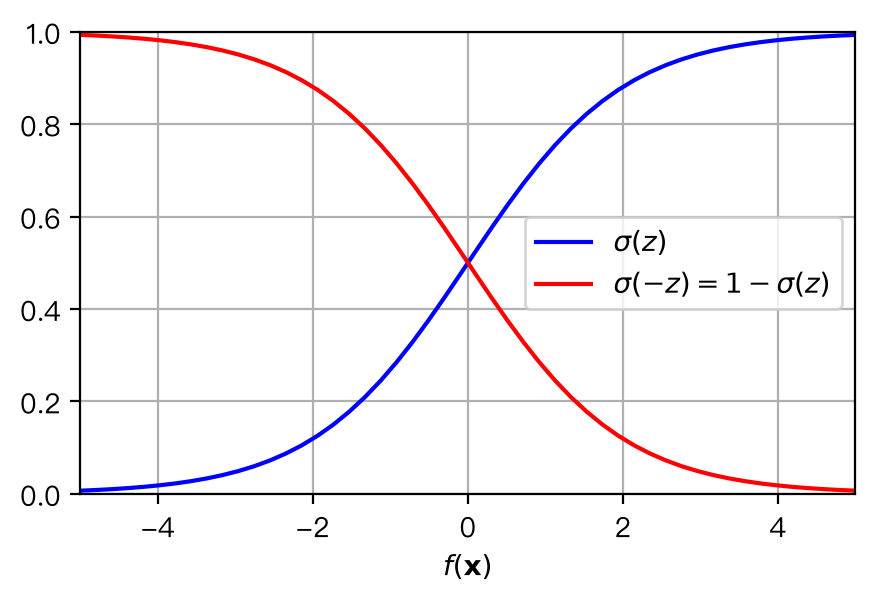

In [18]:
sigmoidplot

- 因此：
  $$p(y|\mathbf{x}) = \begin{cases}\sigma(f(\mathbf{x})), & y=1 \\ \sigma(-f(\mathbf{x})), & y=-1\end{cases}$$
- 可将两种情况合并成一个方程：
  $$p(y|\mathbf{x}) = \sigma(y f(\mathbf{x}))$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>$y f(\mathbf{x})$ 称为带符号的间隔或正确性得分：其符号表示是否分对。</div>


- 取对数：
$$\begin{aligned}\log p(y|\mathbf{x}) &= \log \sigma(y f(\mathbf{x})) \\
    &= \log \frac{1}{1+e^{-y f(\mathbf{x})}} \\
    &= -\log (1+e^{-y f(\mathbf{x})}) \end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>这一形式把概率模型转化为可优化的损失函数。</div>


- 代入最大似然估计形式：
$$\begin{aligned}(\mathbf{w}^*,b^*) &= \mathop{\mathrm{argmax}}_{\mathbf{w},b} \sum_{i=1}^N \log p(y_i|\mathbf{x}_i) \\ 
 &= \mathop{\mathrm{argmin}}_{\mathbf{w},b} \sum_{i=1}^N \log (1+e^{-y_i f(\mathbf{x}_i)}) \end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>argmax 变为 argmin 是因为对数似然前取了负号。</div>


- 右侧的项是**数据拟合项**：
    - 它促使参数 $(\mathbf{w},b)$ 尽量拟合数据。
    - 定义 $z_i = y_i f(\mathbf{x}_i)$：
      - $z_i > 0$ 时，样本 $\mathbf{x}_i$ 被正确分类。
      - $z_i < 0$ 时，样本 $\mathbf{x}_i$ 被错误分类。
      - $z_i = 0$ 时，样本位于分类边界上。
    - 逻辑损失函数：$L(z_i) = \log (1+\exp(-z_i))$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>逻辑损失对严重分错的样本给予大惩罚，对已分对但靠近边界的样本仍有非零惩罚。</div>


In [19]:
z = linspace(-6,6,100)
logloss = log(1+exp(-z)) / log(2)
lossfig = plt.figure()
plt.plot(z,logloss, 'b-')
plt.plot([0,0], [0,9], 'k--')
plt.text(0,8.5, "分类错误 $\\Leftarrow$ ", ha='right', weight='bold')
plt.text(0,8.5, " $\Rightarrow$ 分类正确", ha='left', weight='bold')
plt.annotate(text="严重分错的样本\n产生较大损失", 
             xy=(-4,5.8), xytext=(-4.5,7.2),backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="分类正确但靠近边界的样本\n仍产生非零损失", 
             xy=(1,0.5), xytext=(0.5,3.2), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.xlabel('$z_i$'); plt.ylabel('损失')
plt.title('逻辑损失');  plt.grid(True)
plt.xlim(-6,6)
plt.close()

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


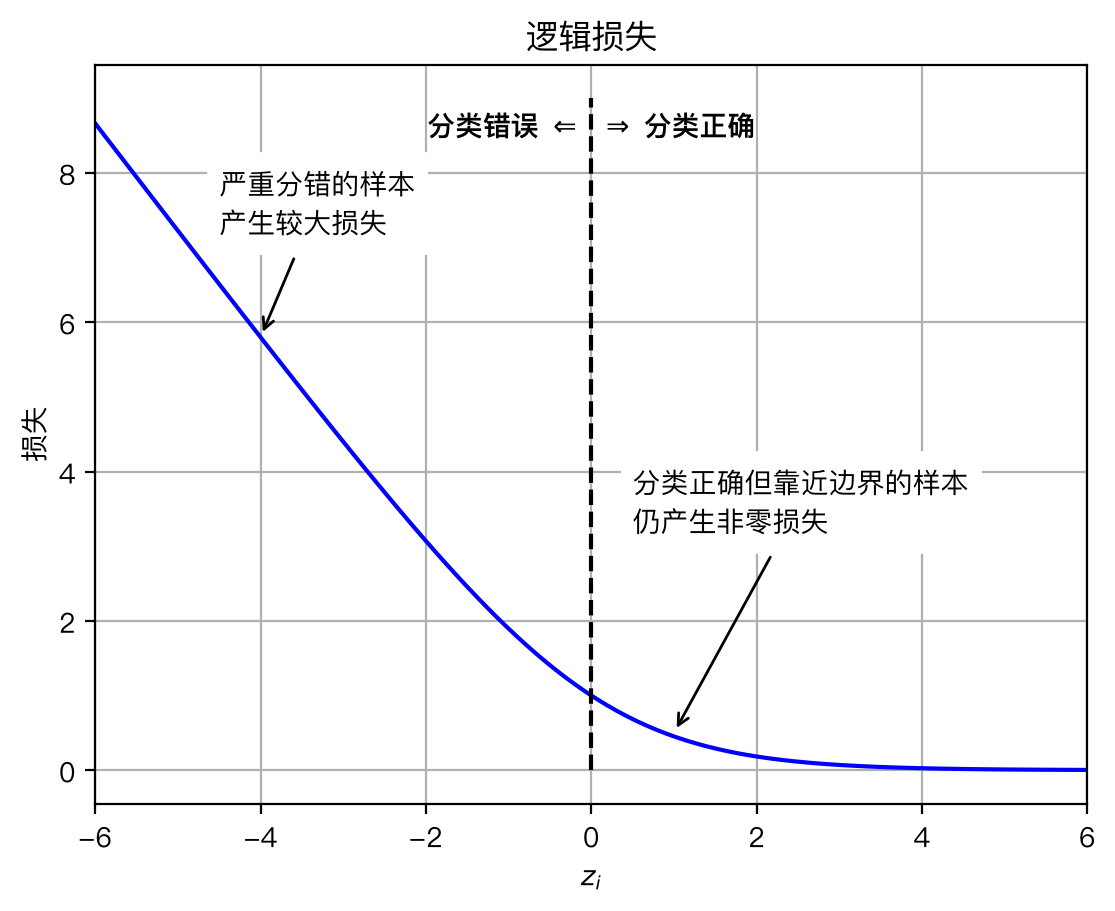

In [20]:
lossfig

# 正则化

- 为了防止**过拟合**，在 $\mathbf{w}$ 上加入先验分布：
  - 偏好先验分布下概率较高的解。
  $$(\mathbf{w}^*,b^*) = \mathop{\mathrm{argmax}}_{\mathbf{w},b} \log p(\mathbf{w}) + \sum_{i=1}^N \log p(y_i|\mathbf{x}_i)$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>从贝叶斯角度看，这是最大后验估计（MAP）；从优化角度看，它对大权重加入惩罚。</div>


- 假设 $\mathbf{w}$ 服从方差为 $C/2$ 的高斯分布：
    - $p(\mathbf{w}) = {\cal N}(\mathbf{w}|0,\frac{C}{2}\mathbf{I})$
      - 较小的 $C$ 使 $\mathbf{w}$ 更接近 0。
      - 较大的 $C$ 允许 $\mathbf{w}$ 取更大的值。
    - $\log p(\mathbf{w}) = -\frac{1}{C} \mathbf{w}^T\mathbf{w} + \text{常数}$

<center><img src="imgs/GaussianPlot.svg" width=400></center>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>零均值高斯先验对应 L2 正则化，它倾向于让所有权重都较小。</div>


- 代入后得：
  $$(\mathbf{w}^*,b^*) = \mathop{\mathrm{argmin}}_{\mathbf{w},b} \frac{1}{C} \mathbf{w}^T\mathbf{w} + \sum_{i=1}^N \log (1+\exp(-y_i f(\mathbf{x}_i)))$$
- 第一项是**正则化项**：
  - $\mathbf{w}^T\mathbf{w} = \sum_{j=1}^d w_j^2$。
  - 它是一个防止 $\mathbf{w}$ 中各元素过大的惩罚项。
  - $C$ 是正则化**超参数**：
    - $C$ 越大，对大权重的惩罚越小，允许 $\mathbf{w}$ 较大。
    - $C$ 越小，对大权重的惩罚越强，抑制 $\mathbf{w}$ 变大。
- 第二项是与之前相同的**数据拟合项**。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>在 scikit-learn 的惯例中，$C$ 是正则化强度的倒数；记住“$C$ 大，正则化弱”。</div>


# 优化

- **没有闭式解**：
  - 需要使用迭代优化算法寻找最优解。
  - 例如**梯度下降**：每次迭代都沿下坡方向移动一步。
    - $\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{d E}{d\mathbf{w}}$
    - $E$ 是目标函数。
    - $\eta$ 是**学习率**，决定每次迭代的步长。
<center><img src="imgs/graddescent.png" width=400></center>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>学习率过大可能震荡或发散，过小则收敛缓慢。实际库可能使用比基本梯度下降更高效的求解器。</div>


# 示例：Iris 数据

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>以花瓣长度和花萼宽度为特征，演示二类逻辑回归的训练、概率图和测试准确率。</div>


In [21]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（变色鸢尾=1，弗吉尼亚鸢尾=2） 
                     #  --> 训练分类器时会自动映射为 (-1, +1)

print(X.shape)

(100, 2)


In [22]:
# 散点图颜色映射：类别 -1 为红色，类别 +1 为绿色
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

axbox = [2.5, 7, 1.5, 4] # 统一的坐标轴范围

# 用于统一设置图形的函数
def irisaxis(axbox):
    plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
    plt.axis(axbox); plt.grid(True)

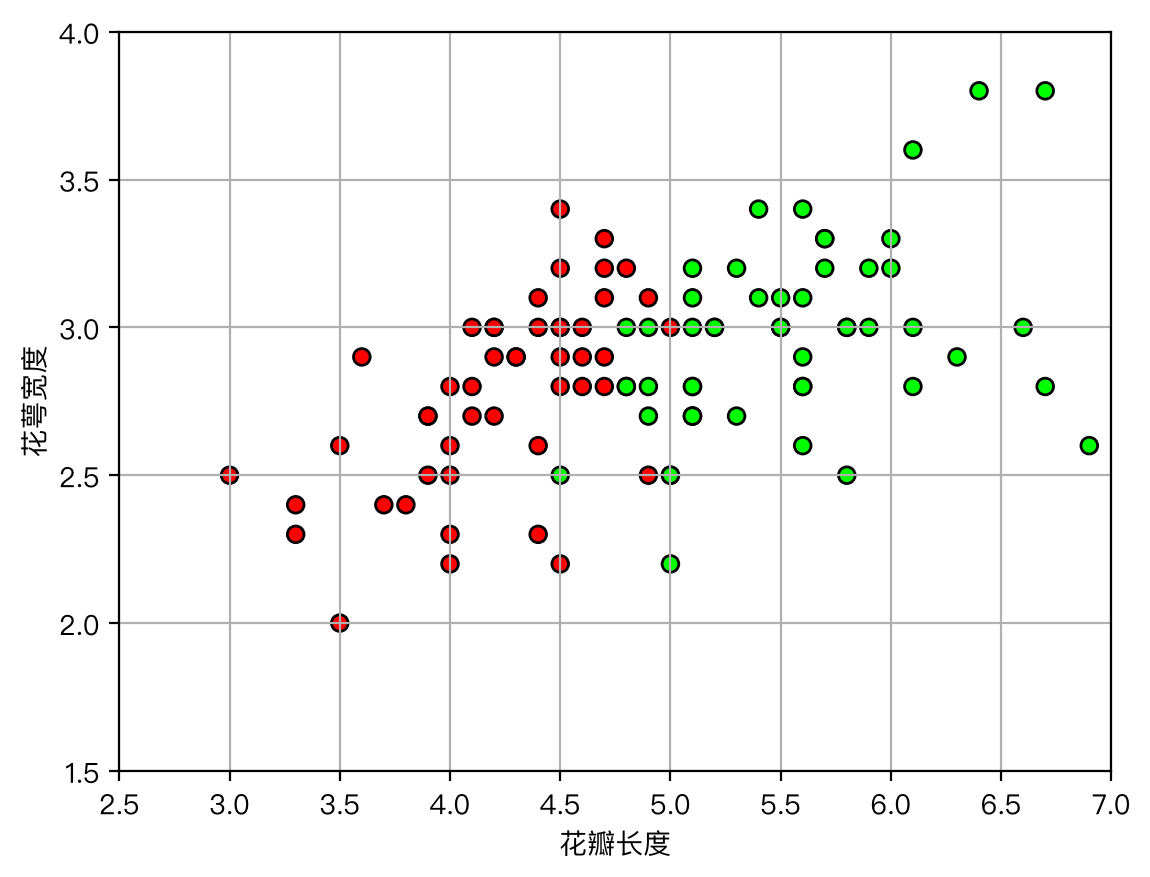

In [23]:
# 显示数据
plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
irisaxis(axbox)

In [24]:
# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(50, 2)
(50, 2)


In [25]:
# 学习逻辑回归分类器
#（C 是正则化超参数）
logreg = linear_model.LogisticRegression(C=100)
logreg.fit(trainX, trainY)

print("w =", logreg.coef_)
print("b =", logreg.intercept_)

w = [[9.53947455 0.8988902 ]]
b = [-48.82195461]


- 方程：
  - $f(\mathbf{x}) = (9.51 * \mathrm{花瓣长度}) + (0.895 * \mathrm{花萼宽度}) - 48.68$
- 解释：
  - 花瓣长度越大，$f(\mathbf{x})$ 越倾向为正，因此较大的花瓣长度与类别 $+1$ 相关。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>权重的正负表示特征对正类得分的影响方向；权重大小只宜在特征量纲可比时直接比较。</div>


In [26]:
def plot_posterior(model, axbox, mycmap, showlabels=True):
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # 创建用于计算后验概率的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    # 计算后验概率
    post = model.predict_proba(allpts)
    # 取出类别 2 的后验概率，并重塑为网格
    post1 = post[:,1].reshape(xgrid0.shape)

    # 绘制后验概率等高线和决策边界
    plt.imshow(post1, origin='lower', extent=axbox, alpha=0.50, cmap=mycmap, vmin=0.0, vmax=1.0)
    if showlabels:
        plt.colorbar(shrink=0.6)
    CS = plt.contour(xr[0], xr[1], post1, colors='k', linestyles='dashed', levels=[0.1, 0.3, 0.7, 0.9], alpha=0.8, linewidths=1)
    if showlabels:
        #plt.colorbar(CS)
        plt.clabel(CS, inline=1, fontsize=10)
    plt.contour(xr[0], xr[1], post1, levels=[0.5], linewidths=2, colors='black')
    irisaxis(axbox)


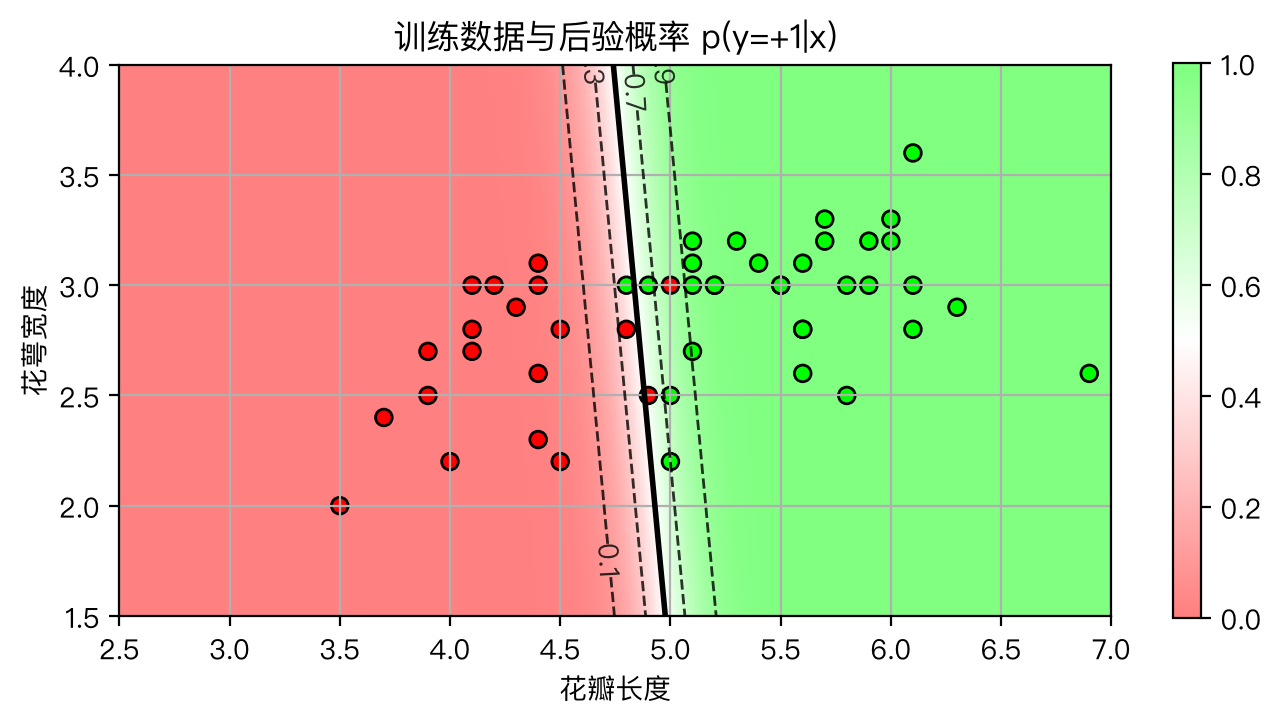

In [27]:
# 显示后验概率和训练数据
plt.figure(figsize=(8,6))
plot_posterior(logreg, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.title('训练数据与后验概率 p(y=+1|x)');

In [28]:
# 使用模型进行预测
predY = logreg.predict(testX)

# 计算准确率
acc = metrics.accuracy_score(testY, predY)
print("测试准确率 =", acc)

测试准确率 = 0.92


In [29]:
# 显示后验概率和训练数据
postfig = plt.figure(figsize=(8,6))
plot_posterior(logreg, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, marker="o", label="训练集", edgecolors='k')
plt.scatter(testX[:,0], testX[:,1], c=testY, cmap=mycmap, marker="s", label="测试集", edgecolors='k')
plt.title('测试数据与后验概率 p(y=+1|x)');
plt.legend(loc=0);
plt.close()

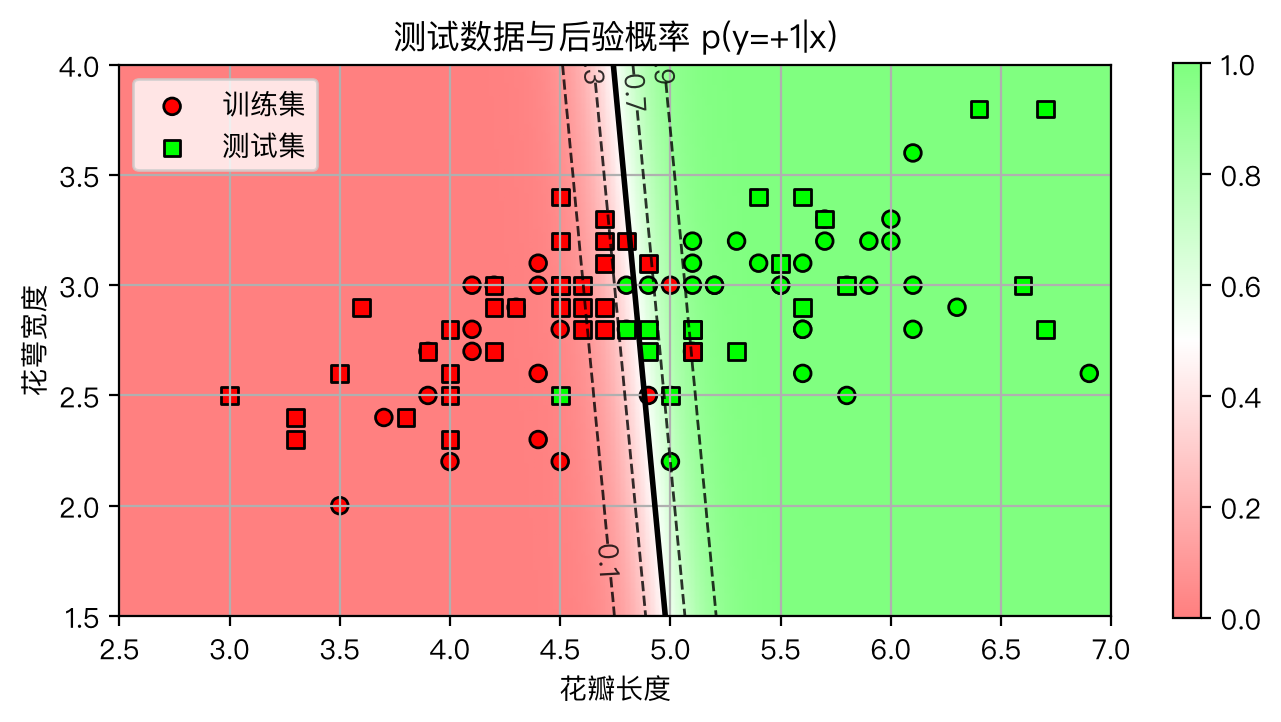

In [30]:
postfig

# 选择正则化超参数
- 正则化超参数 $C$ 会显著影响决策边界和准确率：
  - 较大的 $C$ 使分类器更自信（后验概率更容易饱和到 0 或 1）：
    - 更容易过拟合。
  - 较小的 $C$ 使分类器不那么自信（后验概率的过渡范围更宽）：
    - 较不容易过拟合。
- 应该如何设定 $C$？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>不应在最终测试集上反复尝试 $C$，否则测试集会间接参与模型选择，产生乐观偏差。</div>


In [31]:
lrC = plt.figure(figsize=(10,4.5))

allC = [10000,100, 10, 1, 0.1, 0.01]
for (myCind,myC) in enumerate(allC):
    logreg = linear_model.LogisticRegression(C=myC)
    logreg.fit(trainX, trainY)
    
    # 使用模型进行预测
    predY = logreg.predict(testX)

    # 计算准确率
    acc = metrics.accuracy_score(testY, predY)
    
    plt.subplot(2,3,myCind+1)
    plot_posterior(logreg, axbox, mycmap, showlabels=False)
    plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
    plt.title('C='+str(myC)+"; 准确率="+str(acc));
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
plt.close()

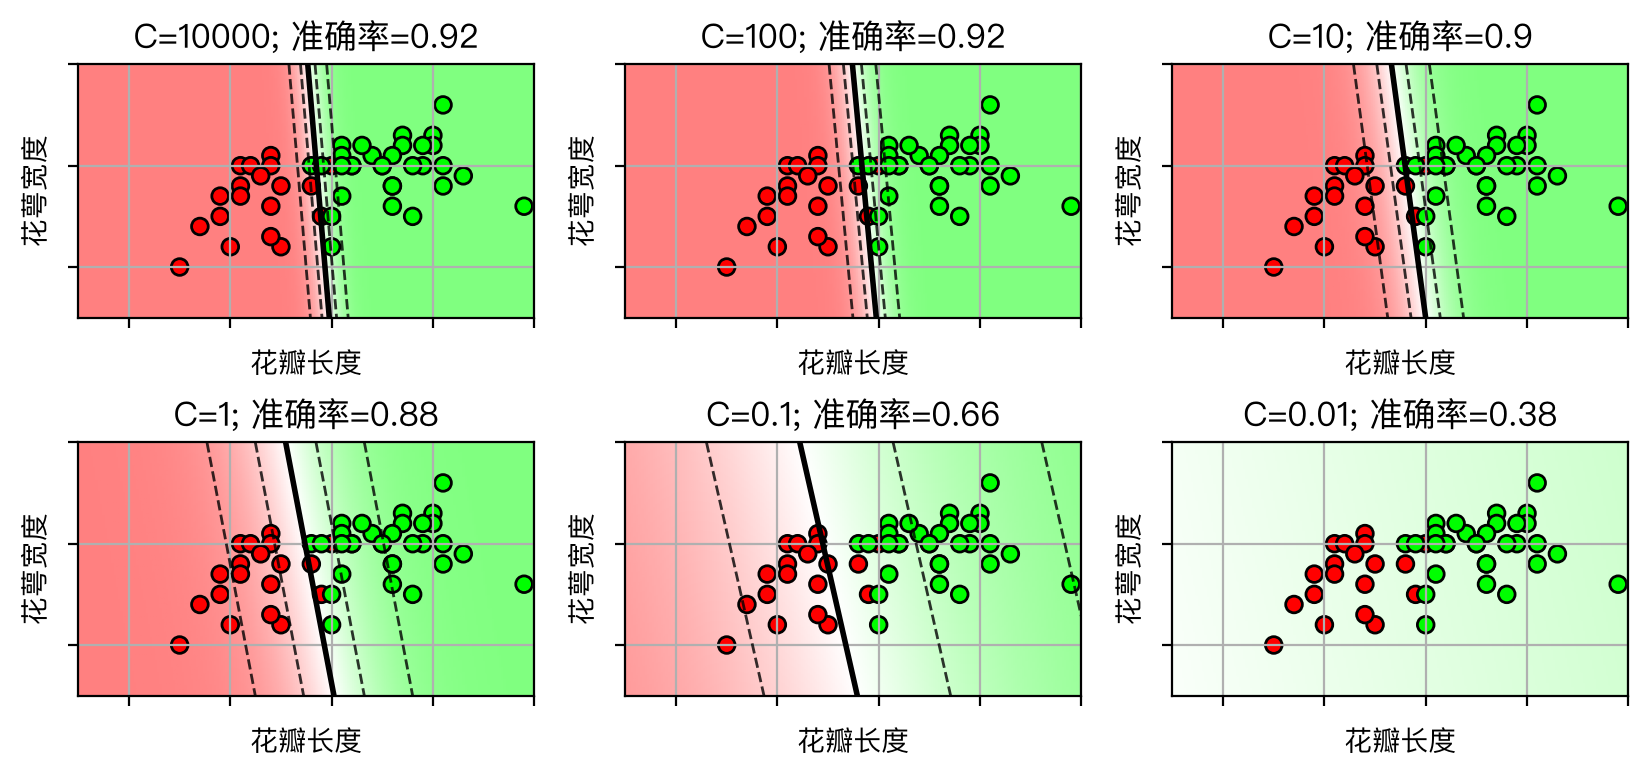

In [32]:
lrC

# 交叉验证
- 在训练集上使用**交叉验证**选择最优 $C$。
  - 在训练集的不同划分上进行多次实验，观察哪些参数在不同数据子集上表现良好：
    - 将数据划分为子训练数据和验证数据。
    - 在每次划分上尝试一系列 $C$ 值。
    - 选择在所有划分上整体表现最好的值。
<center><img src="imgs/10_fold_cv.png" width="500px"/></center>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>交叉验证用于选超参数，最终测试集只应在模型确定后用于一次性评估。</div>


- **步骤**
  1. 选定一组要尝试的 $C$ 值。
  2. 重复 $K$ 次：
    1. 将训练集划分为子训练集和验证集。
    2. 对每个 $C$ 值学习一个分类器。
    3. 记录每个 $C$ 在验证数据上的准确率。
  3. 选择所有 $K$ 折上平均准确率最高的 $C$。
  4. 使用全部训练数据和选定的 $C$ 重新训练分类器。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>选出 $C$ 后必须在完整训练集上重训，否则会浪费某一折的验证数据。</div>


- scikit-learn 已内置交叉验证模块（后续详述）。
- 对于逻辑回归，可使用 `LogisticRegressionCV` 类。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>当前 scikit-learn 的通用交叉验证工具位于 `sklearn.model_selection`；本例直接使用 `LogisticRegressionCV`。</div>


In [33]:
# 使用交叉验证学习逻辑回归分类器
# Cs 是候选 C 值数组
# cv 是折数
# n_jobs=-1 表示使用所有 CPU 核并行运行
logreg = linear_model.LogisticRegressionCV(Cs=logspace(-4,4,20), cv=5, n_jobs=-1)
logreg.fit(trainX, trainY)

print("w=", logreg.coef_)
print("b=", logreg.intercept_)

# 使用模型进行预测
predY = logreg.predict(testX)

# 计算准确率
acc = metrics.accuracy_score(testY, predY)
print("测试准确率=", acc)

/Users/Link/miniforge3/envs/BY/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/Link/miniforge3/envs/BY/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/Users/Link/miniforge3/envs/BY/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remo

w= [[4.62056477 0.72461222]]
b= [-24.25601763]
测试准确率= 0.9


# 最终选择了哪个 $C$？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>下方曲线给出每个 $C$ 的平均交叉验证准确率，峰值对应所选超参数。</div>


C = [4.2813324]


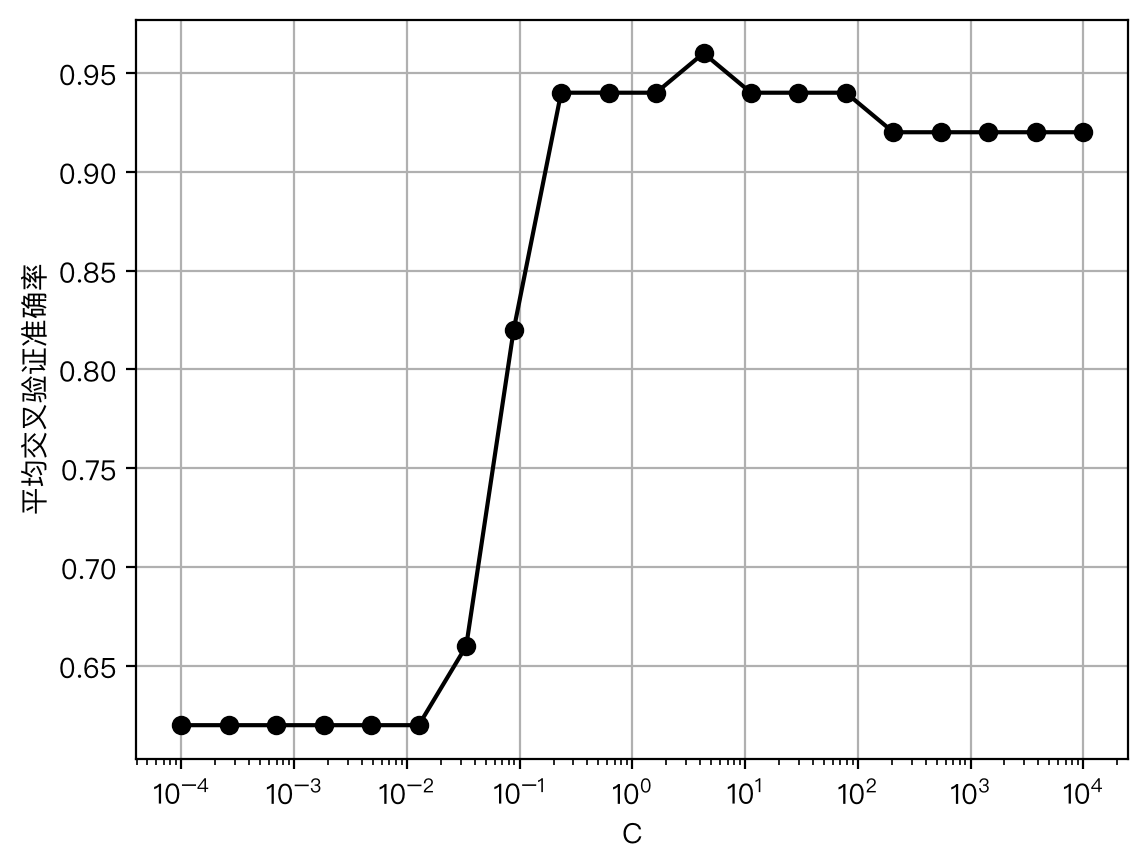

In [34]:
print("C =", logreg.C_)
# 计算每个 C 的平均得分
avgscores = mean(logreg.scores_[2],0)  # 2 是类别标签
plt.semilogx(logreg.Cs_, avgscores, 'ko-')
plt.xlabel('C'); plt.ylabel('平均交叉验证准确率'); plt.grid(True);

# 多类分类
- 到目前为止，我们只学习了用于两个类别（$+1$ 和 $-1$）的分类器：
  - 这称为**二元分类器**。
- 对于超过两个类别的问题，可将它拆分为多个二元分类问题：
  - **一对其余（1-vs-rest）**
    - **训练：**对每个类别，训练一个“该类别对其他所有类别”的分类器。
      - 例如三类问题需训练三个二元分类器：$1$ 对 $\{2,3\}$，$2$ 对 $\{1,3\}$，$3$ 对 $\{1,2\}$。
    - **预测：**计算每个二元分类器的概率，选择概率最高的类别。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>OvR 需要训练 $K$ 个二元分类器；各分类器的输出需要放在同一标准下比较。</div>


# 示例：三类 Iris 数据

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>三类 Iris 数据包含 setosa、versicolor 和 virginica，下面比较 OvR 与直接多类建模。</div>


In [35]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris3.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（山鸢尾=0，变色鸢尾=1，弗吉尼亚鸢尾=2）

print(X.shape)

(150, 2)


In [36]:
# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(75, 2)
(75, 2)


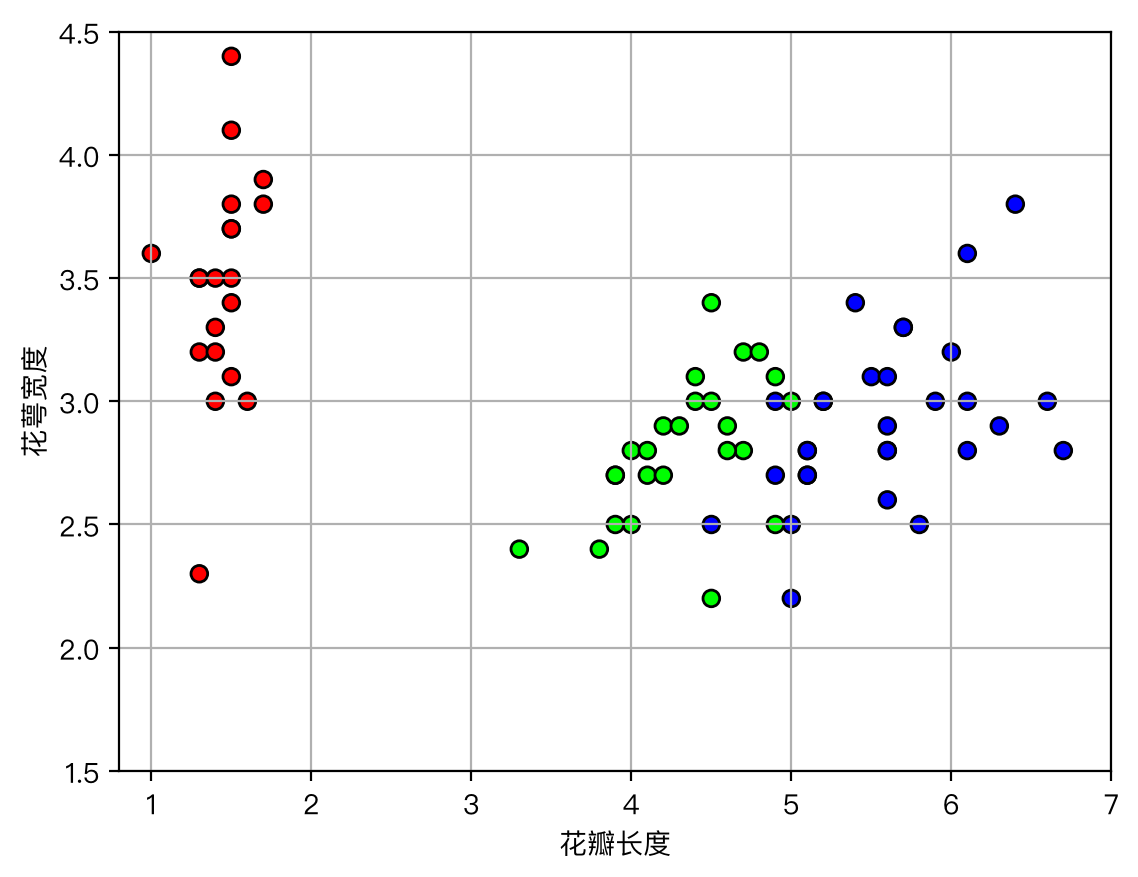

In [37]:
# 查看训练数据

axbox3 = [0.8, 7, 1.5, 4.5]
# 创建用于显示三个类别的颜色映射
mycmap3 = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#00FF00", "#0000FF"])

plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap3, edgecolors='k')
plt.axis(axbox3); plt.grid(True);
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度');

In [38]:
# 学习逻辑回分类器（一对其余）
mlogreg = linear_model.LogisticRegression(C=10, multi_class='ovr')
mlogreg.fit(trainX, trainY)

# 现在包含 3 个超平面和 3 个偏置项（每类一个）
print("w=", mlogreg.coef_)
print("b=", mlogreg.intercept_)

# 使用模型进行预测
predY = mlogreg.predict(testX)

# 计算准确率
acc = metrics.accuracy_score(testY, predY)
print("测试准确率=", acc)

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
def plot_1vr_classifiers(logreg, mlogreg, axbox, mycmap, trainX, trainY, titstr):
    # 绘制每个分类器（假设共 3 个）
    for i in range(3):
        plt.subplot(1,3,i+1)
        # 构建二元模型
        ilogreg = linear_model.LogisticRegression(logreg)
        ilogreg.coef_ = mlogreg.coef_[i,:].reshape(1,2)
        ilogreg.intercept_ = mlogreg.intercept_[i].reshape(1,) 
        ilogreg.classes_ = array([1, 2])
        itrainY = (trainY == i)
        
        plot_posterior(ilogreg, axbox, mycmap, showlabels=False)
        plt.scatter(trainX[:,0], trainX[:,1], c=itrainY, cmap=mycmap, edgecolors='k')

        plt.gca().xaxis.set_ticklabels([])
        plt.gca().yaxis.set_ticklabels([])
        plt.title(titstr.format(i))

mlrfig = plt.figure(figsize=(9,6))
plot_1vr_classifiers(logreg, mlogreg, axbox3, mycmap, trainX, trainY, "类别 {} 对其余类别")
plt.close()

- 各个独立的“一对其余”二元分类器

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>每张子图只回答“是否属于当前类别”，因此每个边界仍是二元决策边界。</div>


In [ ]:
print("w=", mlogreg.coef_)
print("b=", mlogreg.intercept_)

mlrfig 

In [ ]:
def plot_posterior3(model, axbox, mycmap):    
    xr = [ arange(0.8,7,0.05) , arange(1.5, 4.5, 0.05) ]
        
    # 创建用于计算后验概率的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    # 预测概率
    Z = model.predict_proba(allpts)
    P = model.predict(allpts)

    # 将概率用作 RGB 颜色
    ZZ = Z.reshape((len(xr[1]), len(xr[0]), 3))

    plt.imshow(ZZ, origin='lower', extent=axbox, alpha=0.50)
    plt.contour(xr[0], xr[1], P.reshape(xgrid0.shape), levels=[0.5,1.5,2.5], linestyles='dashed', colors='black')
    irisaxis(axbox)
    
lr3class = plt.figure()
plot_posterior3(mlogreg, axbox3, mycmap3)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap3, edgecolors='k')
plt.title('类别概率');
plt.close()

- 合并所有“一对其余”分类器得到的最终分类器

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>最终预测通常选择得分或概率最高的类别。</div>


In [ ]:
lr3class

# 多类逻辑回归
- 获得多类分类器的另一种方法是直接定义多类目标函数：
  - 每个类别 $c$ 都有一个权重向量 $\mathbf{w}_c$。
  - 每个类别都有一个线性函数 $f_c(\mathbf{x}) = \mathbf{w}_c^T\mathbf{x}$。
- 使用 **softmax 函数**定义概率：
  - 它类似于二元逻辑回归中的 sigmoid 函数。
 $$p(y=c|\mathbf{x}) = \frac{e^{f_c(\mathbf{x})}}{e^{f_1(\mathbf{x})} + \cdots + e^{f_K(\mathbf{x})}}$$
  - $f_c(\mathbf{x})$ 响应最大的类别将获得最高概率。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>softmax 会将 $K$ 个得分归一化成和为 1 的概率。数值实现时常先减去最大得分以避免指数溢出。</div>


In [ ]:
f1 = linspace(-5,5,101)
f2 = linspace(-5,5,101)

sfmfig = plt.figure(figsize=(10,4))
for i,f3 in enumerate([-1,3]):
    xgrid0, xgrid1 = meshgrid(f1, f2)
    plt.subplot(1,2,i+1)
    p = exp(xgrid0) / (exp(xgrid0) + exp(xgrid1)+exp(f3))

    plt.imshow(p, origin='lower', extent=[-5,5,-5,5], vmin=0, vmax=1)
    plt.colorbar(shrink=0.8)
    CS = plt.contour(f1, f2, p, colors='k', linestyles='dashed', levels=[0.1, 0.3, 0.5, 0.7, 0.9], alpha=0.8, linewidths=1)

    plt.clabel(CS, inline=1, fontsize=10)

    plt.xlabel('$f_1$')
    plt.ylabel('$f_2$')
    plt.title('$p(y=1|\mathbf{x})$, $f_3=' + str(f3) + '$')
plt.close()

- $K=3$ 时的示例：
 $$p(y=1|\mathbf{x}) = \frac{e^{f_1(\mathbf{x})}}{e^{f_1(\mathbf{x})} + e^{f_2(\mathbf{x})} + e^{f_3(\mathbf{x})}}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>所有类别共享同一个分母，某一类得分上升会同时压低其他类的归一化概率。</div>


In [ ]:
sfmfig

# 参数估计

- 使用最大似然估计来估计参数 $\{\mathbf{w}_j\}$。
- 设 $(\mathbf{x}, \mathbf{y})$ 是一对数据样本：
  - $\mathbf{x}$ 是特征向量。
  - $\mathbf{y} = [y_1, \cdots, y_K]$ 是 one-hot 向量；当样本属于类别 $c$ 时 $y_c=1$，其余分量为 0。
- $(\mathbf{x}, \mathbf{y})$ 的数据似然：
     $$\begin{aligned}似然：&&p(\mathbf{y}|\mathbf{x}) &= \prod_{j=1}^K p(y=j|\mathbf{x})^{y_j} \\
  对数似然：&& \log p(\mathbf{y}|\mathbf{x}) &= \sum_{j=1}^K y_j \log p(y=j|\mathbf{x}) \\
  负对数似然：&&  -\log p(\mathbf{y}|\mathbf{x}) &= -\sum_{j=1}^K y_j \log p(y=j|\mathbf{x})\end{aligned}$$
  - 负对数似然等价于**交叉熵损失**。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>one-hot 标签使求和中只保留真实类别的 $-\log p(y=c|\mathbf{x})$，这正是单样本交叉熵。</div>


- 给定数据集 $\{(\mathbf{x}_i, \mathbf{y}_i)\}_{i=1}^N$：
  - 最大化数据的对数似然：
  $$\max_{\{\mathbf{w}_j\}} \sum_{i=1}^N \log p(\mathbf{y}_i|\mathbf{x}_i) = 
  \max_{\{\mathbf{w}_j\}} \sum_{i=1}^N \sum_{j=1}^K y_{ij} \log p(y=j|\mathbf{x}_i)$$
  - 也就是最小化交叉熵损失。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>多类交叉熵是 softmax 最大似然估计对应的损失函数。</div>


In [ ]:
# 学习逻辑回归分类器
mlogreg = linear_model.LogisticRegression(C=10, 
            multi_class='multinomial')  
            # 使用多类模式及其对应求解器
mlogreg.fit(trainX, trainY)

# 现在包含 3 个超平面和 3 个偏置项（每类一个）
print("w=", mlogreg.coef_)
print("b=", mlogreg.intercept_)

# 使用模型进行预测
predY = mlogreg.predict(testX)

# 计算准确率
acc = metrics.accuracy_score(testY, predY)
print("测试准确率=", acc)

In [ ]:
lr3classm = plt.figure()
plot_posterior3(mlogreg, axbox3, mycmap3)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap3, edgecolors='k')
plt.title('类别概率');
plt.close()

In [ ]:
lr3classm

In [ ]:
lr31vr = plt.figure(figsize=(9,6))
plot_1vr_classifiers(logreg, mlogreg, axbox3, mycmap, trainX, trainY, "w{}")
plt.close()

- 各个类别的权重向量共同作用，将特征空间划分成不同区域。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>多类边界不是完全独立学习的；softmax 分母使各类权重在训练中相互竞争。</div>


In [ ]:
print("w=", mlogreg.coef_)
print("b=", mlogreg.intercept_)

lr31vr

# 逻辑回归总结
- **分类器：**
  - 线性函数 $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$。
  - 给定特征向量 $\mathbf{x}$，类别概率为：
    - $p(y=+1|\mathbf{x}) = \sigma( f(\mathbf{x}) )$
    - $p(y=-1|\mathbf{x}) = 1-\sigma( f(\mathbf{x}) )$
    - sigmoid 函数：$\sigma(z) = \frac{1}{1+e^{-z}}$。
  - 逻辑损失函数：$L(z) = \log (1+\exp(-z))$。
- **训练：**
  - 最大化训练数据的似然。
  - 使用正则化防止过拟合。
    - 使用交叉验证选择正则化超参数 $C$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>一条线索串起全节：线性得分 → sigmoid 概率 → 最大似然 → 逻辑损失 → 正则化与交叉验证。</div>


- **分类：**
  - 给定一个新样本 $\mathbf{x}^*$：
    - 选择概率 $p(y|\mathbf{x}^*)$ 最高的类别：
      $$y^*=\begin{cases}+1, p(y=+1|\mathbf{x}^*)>p(y=-1|\mathbf{x}^*) \\ -1, \mathrm{否则}\end{cases}$$
    - 或者直接使用 $f(\mathbf{x}^*)$：
      $$y^* = \begin{cases}+1, f(\mathbf{x}^*)>0 \\ -1, \mathrm{否则}\end{cases} = \mathrm{sign}(f(\mathbf{x}_*))$$
- **扩展到多类：**
  - 每个类别对应一个线性函数，共有 $K$ 个。
  - 使用 softmax 函数计算概率。
  - 最大似然估计等价于最小化交叉熵损失。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结 / 注意：</b>二分类时，比较概率与判断 $f(\mathbf{x})$ 的符号完全等价；多类时选择 softmax 概率最大的类别。</div>
